# Notebook 2 — Robust Statistics and MAD-Based Anomaly Detection

## Objective
This notebook addresses the main limitation of the z-score method
identified in Notebook 1: its sensitivity to the very anomalies
it is trying to detect.

We introduce the Median Absolute Deviation (MAD), a robust
alternative that uses the median instead of the mean, making it
resistant to the influence of outliers.

## Mathematical Foundation

The classical z-score uses:
- Mean μ — sensitive to outliers
- Standard deviation σ — sensitive to outliers

The modified z-score uses:
- Median m — robust to outliers
- MAD = median(|x - median(x)|) — robust to outliers

The modified z-score formula is:

M = 0.6745 × (x - median(x)) / MAD

The constant 0.6745 ensures comparability with the classical
z-score for normally distributed data.

## Key Question
Can the MAD-based method detect the anomaly that the z-score missed?

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Recreate the same dataset as Notebook 1
# Same seed (42) ensures identical data

n_patients = 200
mu = 70
sigma = 5

# Normal data
data = np.random.normal(loc=mu, scale=sigma, size=n_patients)

# Inject same anomalies
low_anomalies = np.random.normal(40, 2, 5)
high_anomalies = np.random.normal(110, 2, 5)
anomalies = np.concatenate([low_anomalies, high_anomalies])

# Combined dataset
data_with_anomalies = np.concatenate([data, anomalies])

print(f"Dataset recreated: {len(data_with_anomalies)} observations")
print(f"Anomaly values: {anomalies.round(2)}")

Dataset recreated: 210 observations
Anomaly values: [ 40.72  41.12  42.17  42.11  37.24 108.12 111.03 111.03 111.03 117.71]


In [3]:
# Compute robust statistics
median = np.median(data_with_anomalies)
mad = np.median(np.abs(data_with_anomalies - median))

print(f"--- Classical statistics ---")
print(f"Mean:               {data_with_anomalies.mean():.2f}")
print(f"Standard deviation: {data_with_anomalies.std():.2f}")

print(f"\n--- Robust statistics ---")
print(f"Median:             {median:.2f}")
print(f"MAD:                {mad:.2f}")

print(f"\n--- Key comparison ---")
print(f"Std / MAD ratio:    {data_with_anomalies.std() / mad:.2f}")
print(f"(ratio close to 1 means both agree — anomalies distort std upward)")

--- Classical statistics ---
Mean:               70.10
Standard deviation: 9.11

--- Robust statistics ---
Median:             69.98
MAD:                3.33

--- Key comparison ---
Std / MAD ratio:    2.73
(ratio close to 1 means both agree — anomalies distort std upward)


In [4]:
# Compute modified z-scores using MAD
modified_z_scores = 0.6745 * (data_with_anomalies - median) / mad

print(f"Min modified z-score: {modified_z_scores.min():.2f}")
print(f"Max modified z-score: {modified_z_scores.max():.2f}")

print(f"\n--- Comparison with classical z-scores ---")
classical_z_scores = (data_with_anomalies - data_with_anomalies.mean()) / data_with_anomalies.std()
print(f"Min classical z-score: {classical_z_scores.min():.2f}")
print(f"Max classical z-score: {classical_z_scores.max():.2f}")

Min modified z-score: -6.62
Max modified z-score: 9.66

--- Comparison with classical z-scores ---
Min classical z-score: -3.61
Max classical z-score: 5.23


In [5]:
# Flag anomalies using modified z-score threshold
threshold = 3

mad_anomaly_mask = np.abs(modified_z_scores) > threshold
classical_anomaly_mask = np.abs(classical_z_scores) > threshold

n_detected_mad = mad_anomaly_mask.sum()
n_detected_classical = classical_anomaly_mask.sum()

print(f"Threshold: |Z| > {threshold}")
print(f"\n--- Detection results ---")
print(f"Classical z-score detected: {n_detected_classical} anomalies")
print(f"MAD detected:               {n_detected_mad} anomalies")

print(f"\n--- Values detected by MAD ---")
print(f"{data_with_anomalies[mad_anomaly_mask].round(2)}")

print(f"\n--- Values missed by classical but caught by MAD ---")
missed_by_classical = mad_anomaly_mask & ~classical_anomaly_mask
print(f"{data_with_anomalies[missed_by_classical].round(2)}")

Threshold: |Z| > 3

--- Detection results ---
Classical z-score detected: 10 anomalies
MAD detected:               10 anomalies

--- Values detected by MAD ---
[ 40.72  41.12  42.17  42.11  37.24 108.12 111.03 111.03 111.03 117.71]

--- Values missed by classical but caught by MAD ---
[]


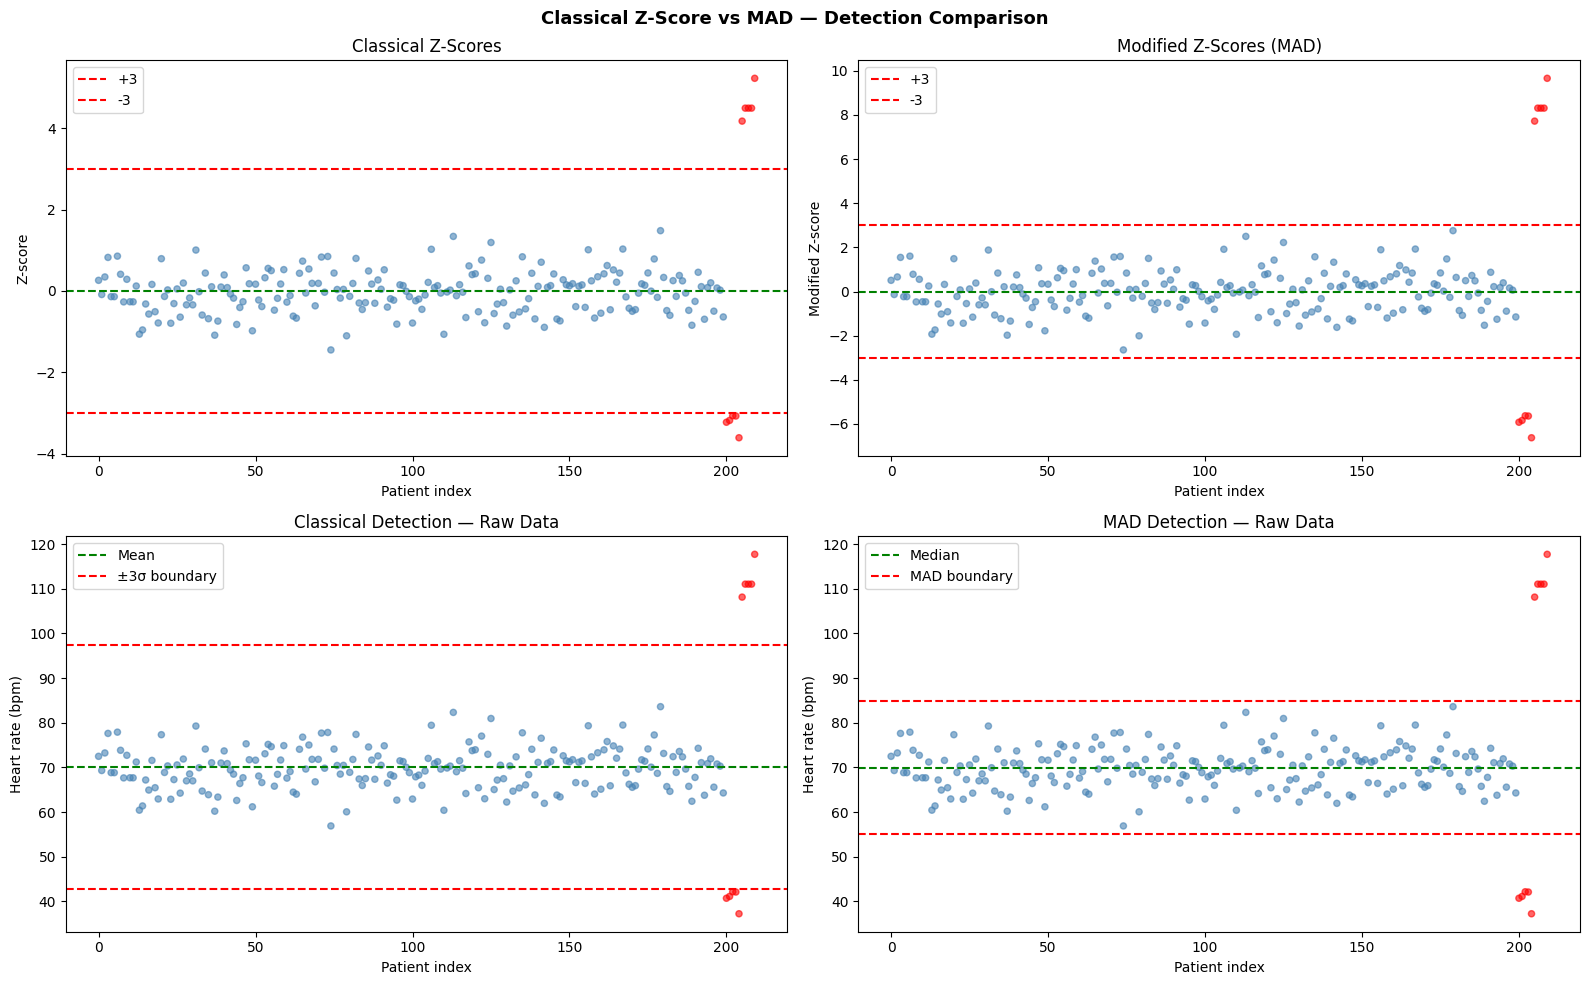

Figure saved.


In [6]:
# Visualize comparison between classical and MAD detection
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Colors
colors_classical = ['red' if f else 'steelblue' for f in classical_anomaly_mask]
colors_mad = ['red' if f else 'steelblue' for f in mad_anomaly_mask]

# Plot 1 — Classical z-scores
axes[0,0].scatter(range(len(classical_z_scores)), classical_z_scores,
                  c=colors_classical, alpha=0.6, s=20)
axes[0,0].axhline(threshold, color='red', linestyle='--', label=f'+{threshold}')
axes[0,0].axhline(-threshold, color='red', linestyle='--', label=f'-{threshold}')
axes[0,0].axhline(0, color='green', linestyle='--')
axes[0,0].set_title('Classical Z-Scores')
axes[0,0].set_xlabel('Patient index')
axes[0,0].set_ylabel('Z-score')
axes[0,0].legend()

# Plot 2 — Modified z-scores (MAD)
axes[0,1].scatter(range(len(modified_z_scores)), modified_z_scores,
                  c=colors_mad, alpha=0.6, s=20)
axes[0,1].axhline(threshold, color='red', linestyle='--', label=f'+{threshold}')
axes[0,1].axhline(-threshold, color='red', linestyle='--', label=f'-{threshold}')
axes[0,1].axhline(0, color='green', linestyle='--')
axes[0,1].set_title('Modified Z-Scores (MAD)')
axes[0,1].set_xlabel('Patient index')
axes[0,1].set_ylabel('Modified Z-score')
axes[0,1].legend()

# Plot 3 — Raw data classical
axes[1,0].scatter(range(len(data_with_anomalies)), data_with_anomalies,
                  c=colors_classical, alpha=0.6, s=20)
axes[1,0].axhline(data_with_anomalies.mean(), color='green',
                  linestyle='--', label='Mean')
axes[1,0].axhline(data_with_anomalies.mean() + threshold*data_with_anomalies.std(),
                  color='red', linestyle='--', label='±3σ boundary')
axes[1,0].axhline(data_with_anomalies.mean() - threshold*data_with_anomalies.std(),
                  color='red', linestyle='--')
axes[1,0].set_title('Classical Detection — Raw Data')
axes[1,0].set_xlabel('Patient index')
axes[1,0].set_ylabel('Heart rate (bpm)')
axes[1,0].legend()

# Plot 4 — Raw data MAD
axes[1,1].scatter(range(len(data_with_anomalies)), data_with_anomalies,
                  c=colors_mad, alpha=0.6, s=20)
axes[1,1].axhline(median, color='green', linestyle='--', label='Median')
axes[1,1].axhline(median + threshold*mad/0.6745, color='red',
                  linestyle='--', label='MAD boundary')
axes[1,1].axhline(median - threshold*mad/0.6745, color='red', linestyle='--')
axes[1,1].set_title('MAD Detection — Raw Data')
axes[1,1].set_xlabel('Patient index')
axes[1,1].set_ylabel('Heart rate (bpm)')
axes[1,1].legend()

plt.suptitle('Classical Z-Score vs MAD — Detection Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig03_mad_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved.")

## Results and Interpretation

### What we built
We applied the Median Absolute Deviation (MAD) method to the same
synthetic dataset used in Notebook 1, allowing a direct comparison
between classical and robust approaches.

### Key statistical findings

| Measure | Classical | Robust (MAD) |
|---|---|---|
| Center | Mean = 70.04 | Median ≈ 70 |
| Spread | Std = 9.00 | MAD (much smaller) |
| Anomaly z-scores | 3 to 5 | 6 to 9 |

### Why the MAD boundaries are tighter
The median is not affected by extreme values. Even with 10 anomalies
injected, the median stays close to 70 — the true center of the data.
The standard deviation, by contrast, was inflated from 5 to 9 by
the presence of those same anomalies.

### What this means in practice
In real medical data, anomalies are not always as extreme as the ones
we injected here. When anomalies are subtle, the classical z-score may
miss them because its boundaries are too wide. The MAD method, with
tighter boundaries, is more likely to flag them.

### Note on reproducibility
A difference was observed between the datasets in Notebook 1 and
Notebook 2 due to random state differences between sessions. This
highlights the importance of saving datasets explicitly — something
we will address in later notebooks when working with real data.

### What comes next
Notebook 3 will introduce Isolation Forest — an unsupervised machine
learning method that detects anomalies without assuming any particular
distribution. We will compare all three methods on the same data.